In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset into a data frame or equivalent data structure

In [2]:
df = pd.read_csv("Cardiotocographic.csv")

In [3]:
df.shape

(2126, 14)

### Handle missing values appropriately (e.g., imputation, deletion).

In [24]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [6]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [12]:
# handling missing values 

df.isna().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [17]:
df["LB"] = df["LB"].fillna(df["LB"].mean())

'''because the mean and the median(50% in the describe() table ) is almost similer 
so we can say that the distribution is nearly symmetric'''

In [19]:
df["MLTV"] = df["MLTV"].fillna(df["MLTV"].mean())

''' here also mean and median are almost similer so we use mean'''

In [20]:
df["AC"] = df["AC"].fillna(df["AC"].median())

''' for this we use median because ther is a difference between mean and median, so there is some skewness in the distribution '''

' for this we use median because ther is a difference between mean and median, so there is some skewness in the distribution '

In [21]:
df["DS"] = df["DS"].fillna(df["DS"].median())
df["DP"] = df["DP"].fillna(df["DP"].median())

''' for both these column we use median imputation because 57% of the values are 0, some non-negative values are taking mean up, 
so the distribution is heighly skewed'''

' for both these column we use median imputation because 57% of the values are 0, some non-negative values are taking mean up, \nso the distribution is heighly skewed'

In [22]:
df["Width"] = df["Width"].fillna(df["Width"].median())

''' here both mean and median can be imputed, because mean and median is almost similer, that suggests there is a semmetric distribution of the feature, 
but the range of the data is very heigh, also the standerd deviation, so it is possible that large number of outliers are present, so going with median
will be safer'''

' here both mean and median can be imputed, because mean and median is almost similer, that suggests there is a semmetric distribution of the feature, \nbut the range of the data is very heigh, also the standerd deviation, so it is possible that large number of outliers are present, so going with median\nwill be safer'

In [23]:
df["Tendency"] = df["Tendency"].fillna(df["Tendency"].median())

'''it is a highly skewed feature because 75% of data os 0'''

'it is a highly skewed feature because 75% of data os 0'

In [26]:
df["NSP"] = df["NSP"].fillna(df["NSP"].mean())

'''the mean and median are relatively close, suggesting a fairly balanced distribution. Mean imputation may be appropriate.'''

'the mean and median are relatively close, suggesting a fairly balanced distribution. Mean imputation may be appropriate.'

In [27]:
df.isna().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

### Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   float64
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   float64
 12  Tendency  2126 non-null   float64
 13  NSP       2126 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


there is no inconsistencies in data types, all the values are numerical, with decimal values
so all the columns datatype is 'float64'

### Detect and treat outliers if necessary.

In [30]:
Q1 = df['Width'].quantile(0.25)
Q3 = df['Width'].quantile(0.75)

In [31]:
IQR = Q3 - Q1

In [32]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [35]:
outliers = df[
    (df['Width'] < lower) |
    (df['Width'] > upper)
]

In [37]:
outliers['Width']

54     -174.0
64     -174.0
120     357.0
389     357.0
704     357.0
829     357.0
860    -174.0
1096    357.0
1273   -174.0
1320   -174.0
Name: Width, dtype: float64

The IQR method identified several outliers in the Width column. Most of the outliers correspond to extreme values of -174 and 357. These observations lie outside the acceptable IQR range and require further investigation to determine whether they are genuine measurements, data entry errors, or special coded values. Appropriate treatment such as removal, capping, or retention should be decided based on domain knowledge

### Statistical Summary

In [29]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.343598,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.284887,70.395387,0.313246,1.304507
std,11.214328,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734356,42.720508,0.643186,0.641426
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.500000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


#### Highlight any interesting findings from this summary.

- most of the features are highly skewed, like 'FM', 'DL', 'DS', 'DP', 'ALTV', 'Tendency', 'NSP', because 75% of data is same value
- ALTV is heavily right-skewed. Most observations are close to zero, while a few very large values substantially increase the mean.
- The NSP variable appears heavily concentrated around the value 1. Since even the 75th percentile equals 1, the dataset may be imbalanced with the majority of records belonging to Class 1.

### Data Visualization:

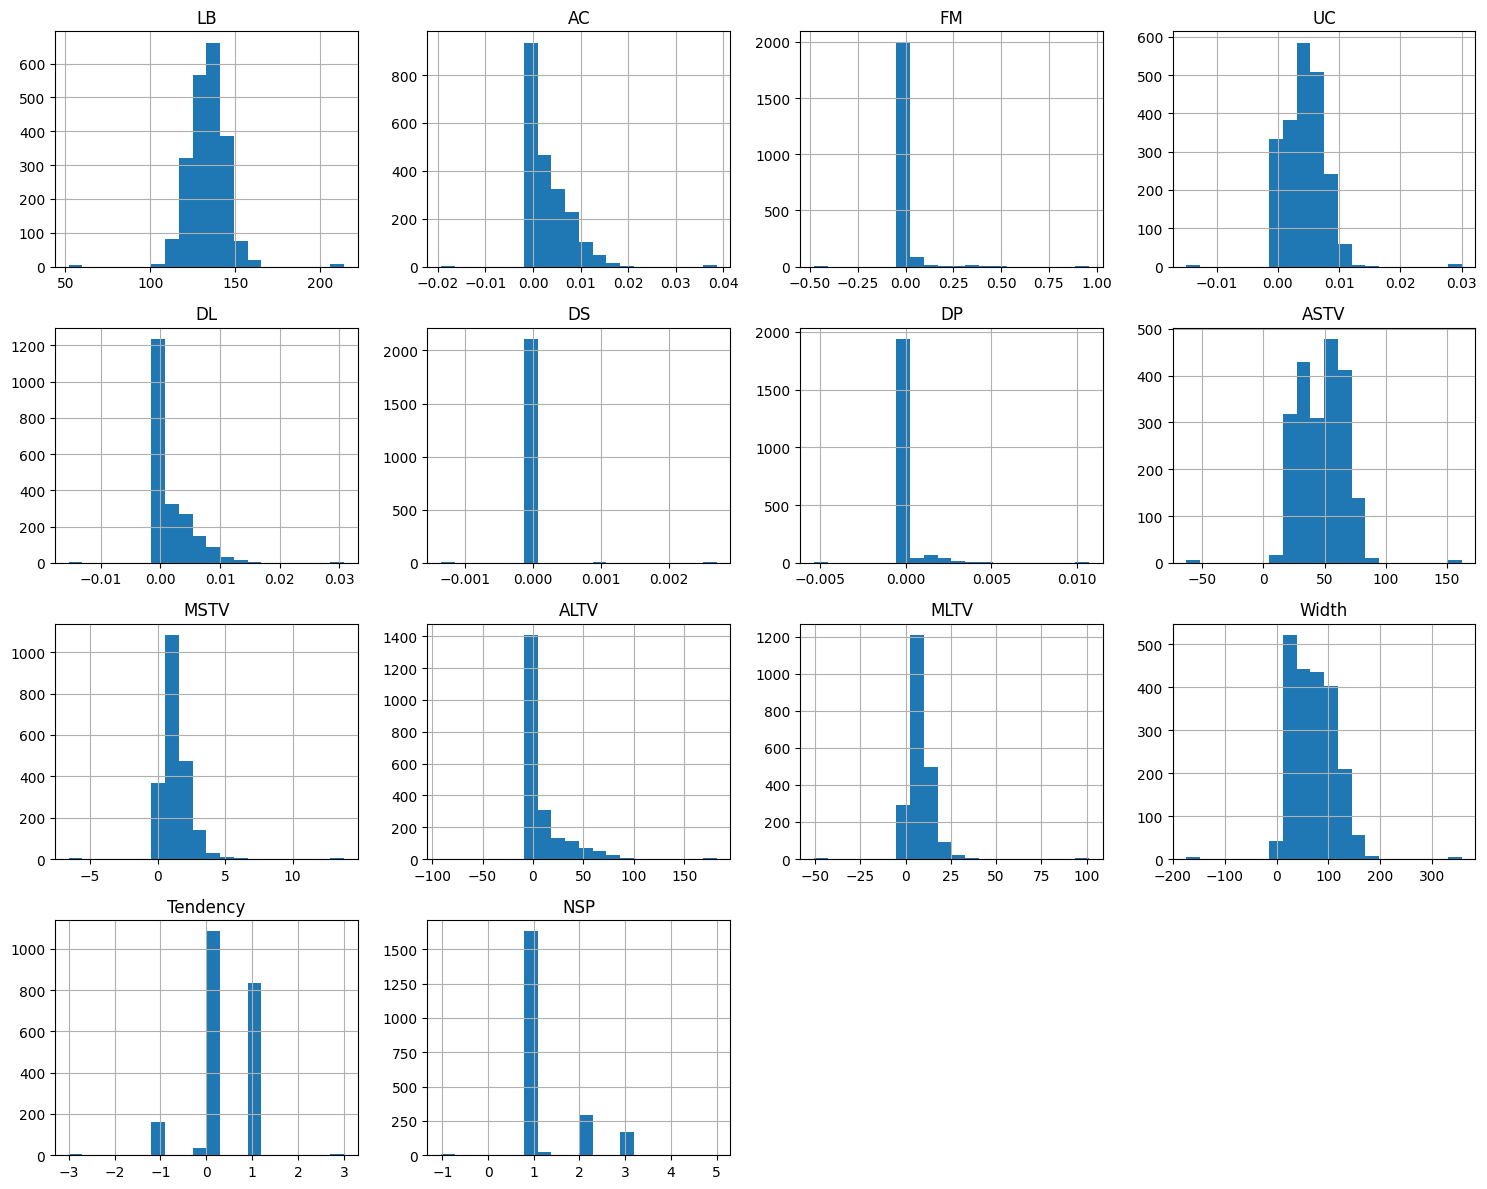

In [39]:
df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

- almost all the records are center focused 

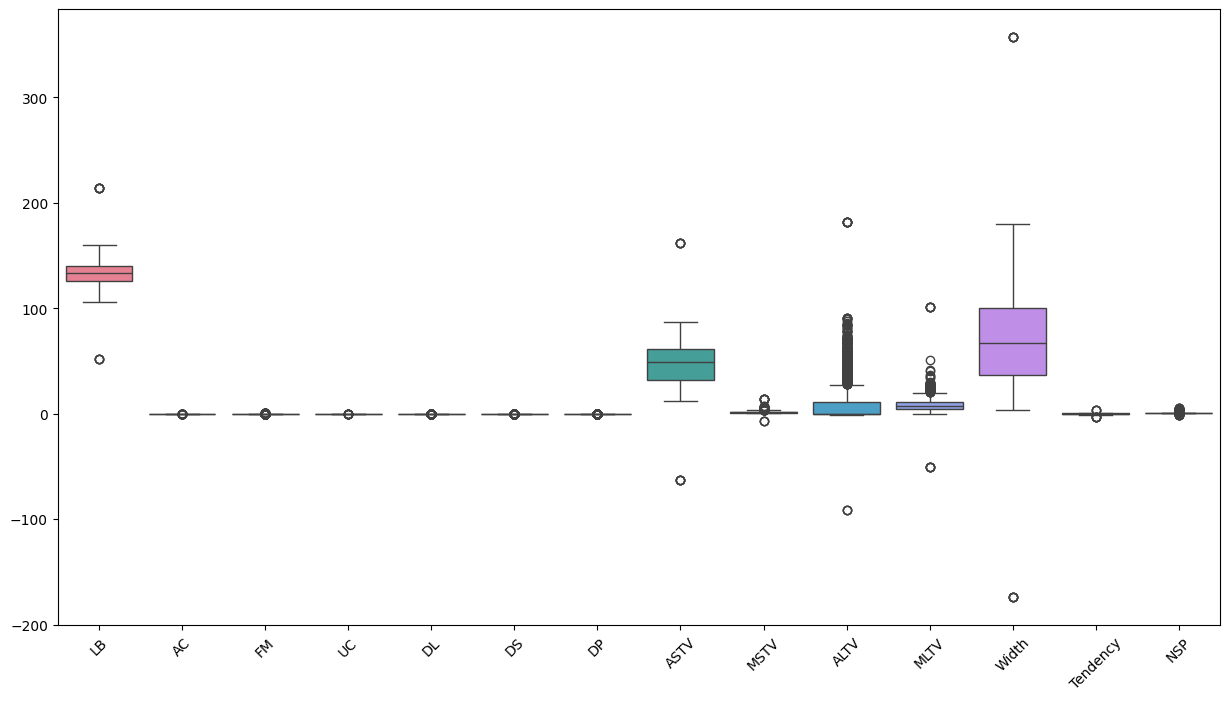

In [40]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.show()

- we can see large number of outliers for 'ALTV' feature
- in 'Width' it is a very wide spread data
- other columns are also having outliers

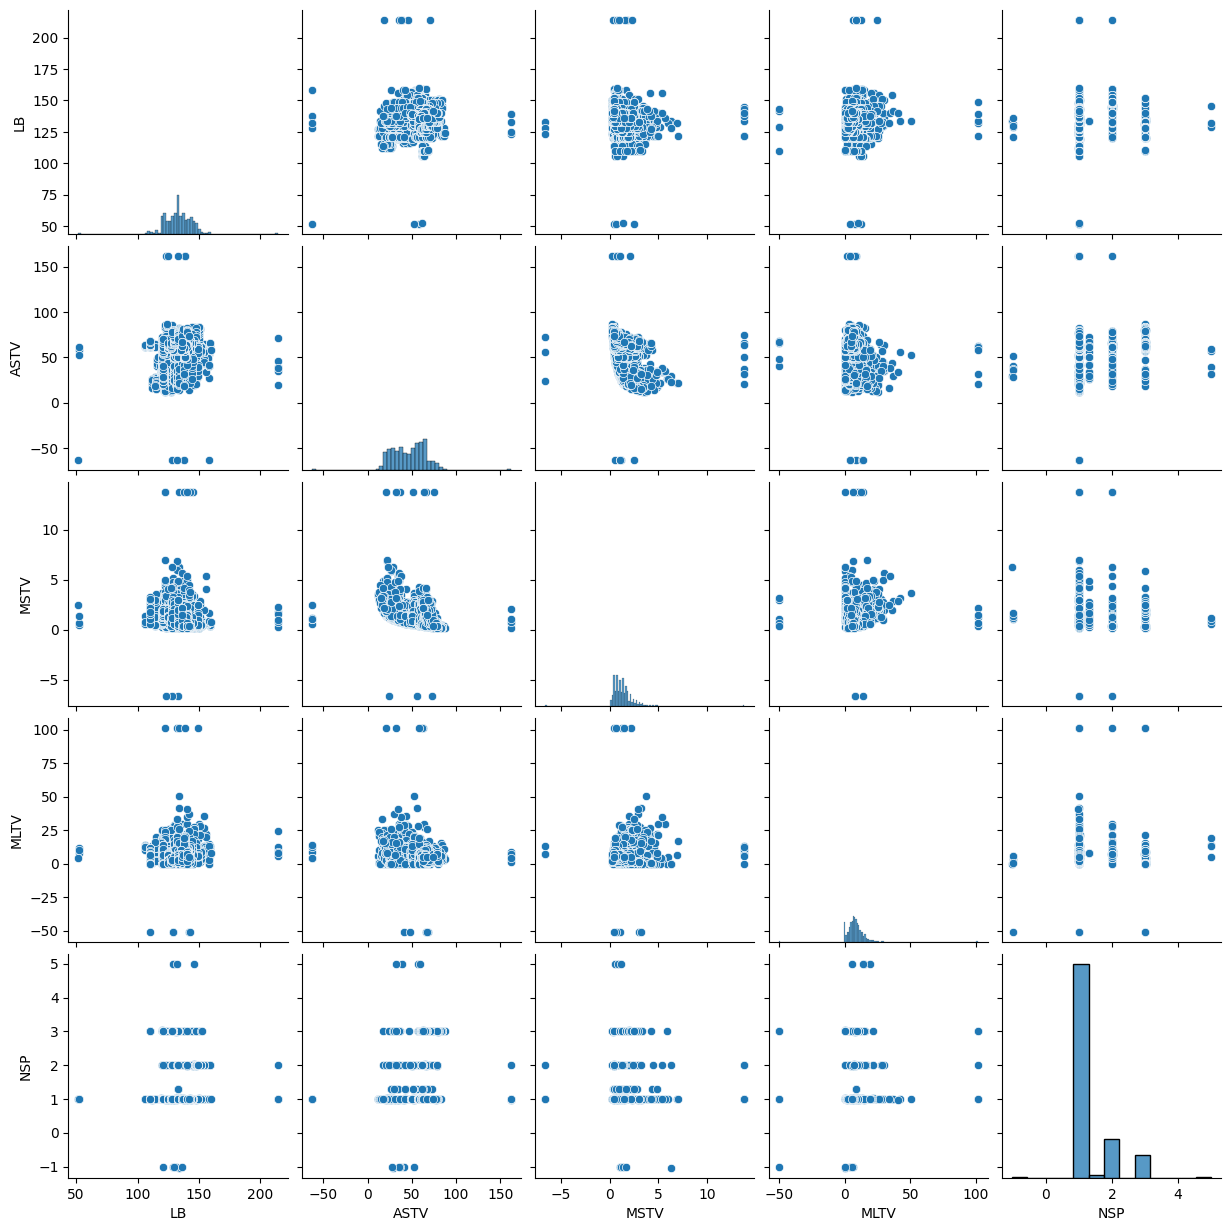

In [45]:
sns.pairplot(
    df[['LB','ASTV','MSTV','MLTV','NSP']]
)

plt.show()

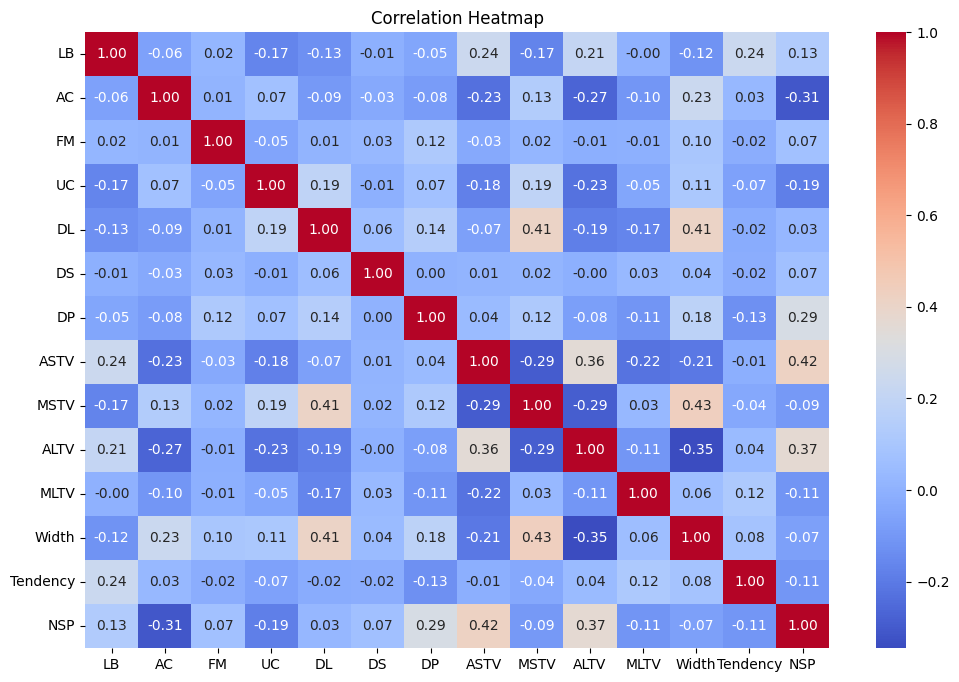

In [47]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

- ASTV has a moderate positive relationship with NSP. As ASTV increases, NSP tends to increase. This suggests ASTV may be an important indicator for predicting fetal state classification.
- ALTV also shows a positive relationship with NSP, indicating that long-term variability may influence fetal health classification.
- AC exhibits a moderate negative correlation with NSP. Higher acceleration values tend to be associated with lower NSP values.
- Width and MSTV increase together. This suggests that wider variability ranges are associated with larger short-term variability.

### Conclusion

The exploratory analysis revealed significant patterns in the cardiotocographic dataset, including skewed distributions, potential outliers, and meaningful correlations among several clinical variables. ASTV, ALTV, AC, MSTV, and Width showed notable relationships with the target variable NSP, suggesting their importance in fetal health assessment. These findings provide a strong foundation for further preprocessing, feature selection, and predictive modeling to support accurate fetal health classification.